In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

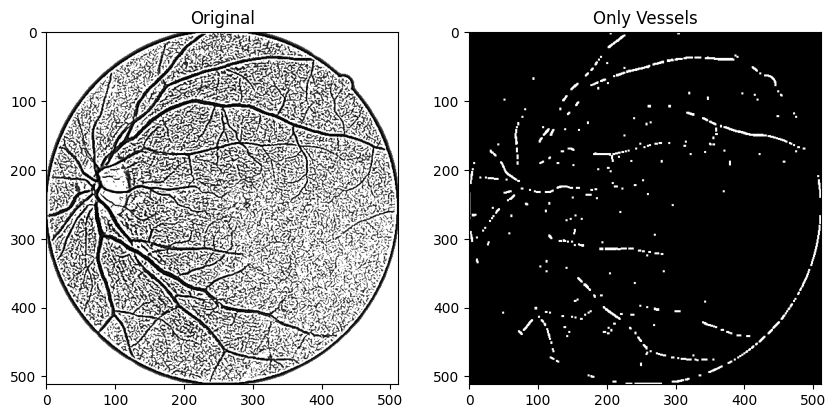

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.morphology import remove_small_objects

# 1. Load Image
img = cv2.imread("/kaggle/input/datasets/amimulahasanrofik/hassanvesselmap/100468003_L.png", 0)  # grayscale

# 2. Contrast Enhance (important)
img = cv2.equalizeHist(img)

# 3. Apply Frangi Filter (vessel enhance)
vessels = frangi(img)

# 4. Normalize to 0-255
vessels = (255 * vessels / vessels.max()).astype(np.uint8)

# 5. Threshold (only vessels keep)
_, binary = cv2.threshold(vessels, 30, 255, cv2.THRESH_BINARY)

# 6. Remove small noise
binary = remove_small_objects(binary.astype(bool), min_size=150)
binary = binary.astype(np.uint8) * 255

# 7. Morphology (clean)
kernel = np.ones((3,3), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 8. Show result
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Only Vessels")
plt.imshow(clean, cmap='gray')

plt.show()